# Comparing Two Models: GLM v GBM

Insurabench allows the user to compare two models by fitting both models to
the same data and producing evaluation charts and analysis. 

This notebook uses a larger synthetic book than notebook 1 with enough signal
for the two model types to meaningfully differ.


## Frequency Models for Claims Data

In [1]:
from insurabench.data.datasets import make_synthetic_two_table
from insurabench.data.policy_frame import PolicyFrame
from insurabench.model_selection import train_test_split_policy_frame
from insurabench.models.glm import GLMPricingModel
from insurabench.models.gbm import GBMPricingModel

book = make_synthetic_two_table(n_policies=4000, renewals=True, seed=7)
pf = PolicyFrame.from_tables(
    book.policies, book.claims, book.policy_schema, book.claims_schema, verbose=False
)
train_pf, test_pf = train_test_split_policy_frame(pf, test_size=0.25, seed=7)

models = {
    "GLM": GLMPricingModel(family="poisson").fit_policy_frame(train_pf, "frequency"),
    "GBM": GBMPricingModel(family="poisson", iterations=200).fit_policy_frame(train_pf, "frequency"),
}
predictions = {name: m.predict_policy_frame(test_pf) for name, m in models.items()}

for name, model in models.items():
    print(f"{name:>3}  Test D² = {model.score_policy_frame(test_pf):.3f}")


GLM  Test D² = -0.024
GBM  Test D² = -0.018


## Lift Charts, Rating Curves and Evaluation Metrics

`one_way_curve`, `relativity_table`, `lift_chart`, `gini_index` all take
a prediction array and a target; they are all model-agnostic allowing
the user to easily compare a variety of models.


--- GLM ---
Gini: 0.114


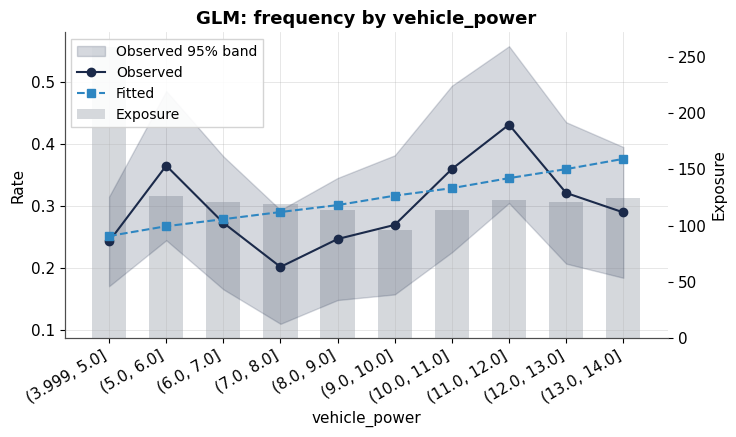

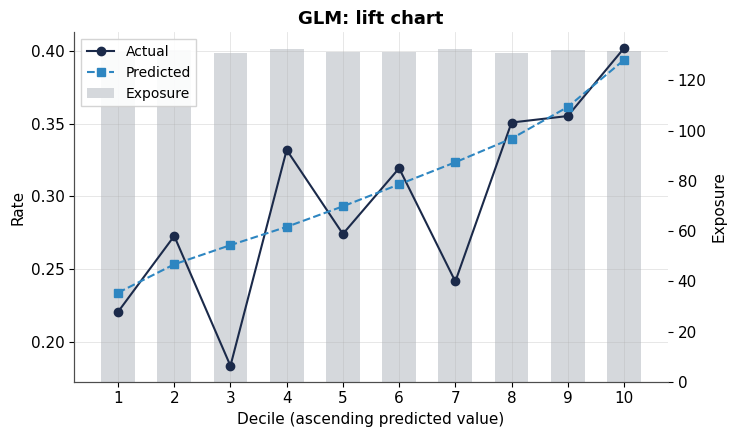

--- GBM ---
Gini: 0.141


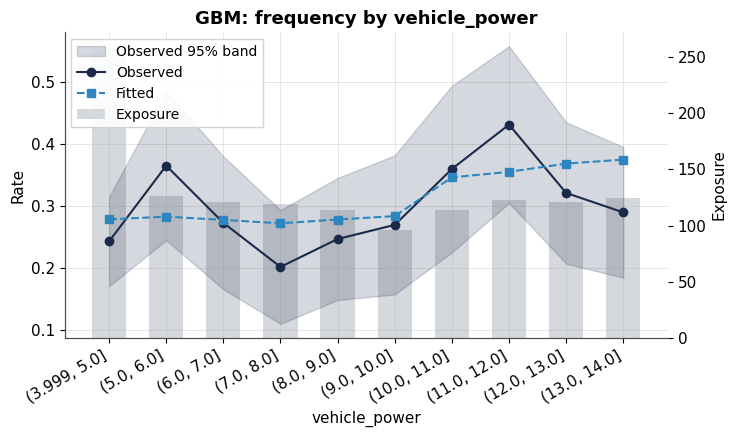

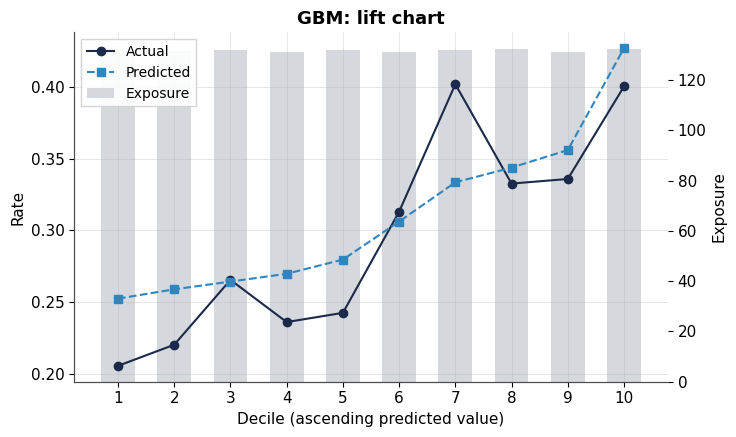

In [2]:
from insurabench.curves import one_way_curve, relativity_table
from insurabench.evaluation import gini_index, lift_chart
from insurabench.viz import plot_one_way_curve, plot_lift_chart

for name, y_pred in predictions.items():
    print(f"--- {name} ---")
    print(f"Gini: {gini_index(test_pf, 'frequency', y_pred):.3f}")

    curve = one_way_curve(test_pf, "vehicle_power", "frequency", y_pred)
    plot_one_way_curve(curve, feature_name="vehicle_power", title=f"{name}: frequency by vehicle_power")

    chart = lift_chart(test_pf, "frequency", y_pred, n_deciles=10)
    plot_lift_chart(chart, title=f"{name}: lift chart")


In [3]:
rel_table_glm = relativity_table(test_pf, "frequency", predictions["GLM"], features=["vehicle_power"])
rel_table_gbm = relativity_table(test_pf, "frequency", predictions["GBM"], features=["vehicle_power"])
rel_table_glm

,feature,level,n_obs,exposure,observed,fitted,relativity
0,vehicle_power,"(3.999, 5.0]",397,259.244,0.243014,0.251716,1.000000
1,vehicle_power,"(5.0, 6.0]",192,125.951,0.365221,0.267543,1.062876
2,vehicle_power,"(6.0, 7.0]",178,120.888,0.272980,0.278883,1.107926
3,vehicle_power,"(7.0, 8.0]",175,118.898,0.201854,0.290435,1.153820
4,vehicle_power,"(8.0, 9.0]",171,113.406,0.246901,0.301619,1.198250
5,vehicle_power,"(9.0, 10.0]",149,96.403,0.269701,0.316837,1.258707
6,vehicle_power,"(10.0, 11.0]",178,113.936,0.359851,0.328917,1.306696
7,vehicle_power,"(11.0, 12.0]",193,122.847,0.431431,0.345128,1.371099
8,vehicle_power,"(12.0, 13.0]",195,121.407,0.321234,0.359671,1.428873
9,vehicle_power,"(13.0, 14.0]",189,124.210,0.289832,0.376185,1.494479


## Compare Two Models Directly

The `double_lift_chart` buckets policies by where the two models disagree
most (the ratio of their predictions), then shows actual outcomes
against both, to answer "which model is actually
better, and where."


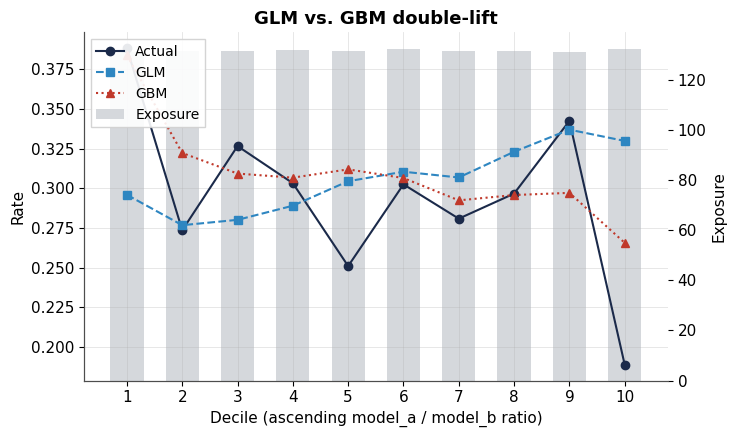

,decile,n_obs,exposure,actual,GLM,GBM,ratio_a_over_b
0,1,200,131.313,0.388385,0.295888,0.383836,0.776314
1,2,202,131.595,0.273567,0.276754,0.322288,0.859500
2,3,203,131.647,0.326631,0.280116,0.309305,0.905818
3,4,193,131.914,0.303228,0.289032,0.306725,0.942142
4,5,205,131.494,0.250962,0.304473,0.311955,0.976036
5,6,203,132.229,0.302506,0.310469,0.306485,1.012973
6,7,200,131.732,0.280873,0.306834,0.292412,1.049521
7,8,206,131.458,0.296673,0.323059,0.295767,1.092013
8,9,203,131.381,0.342515,0.336994,0.297140,1.134102
9,10,202,132.427,0.188783,0.329878,0.265636,1.244029


In [4]:
from insurabench.evaluation import double_lift_chart
from insurabench.viz import plot_double_lift_chart

dl_chart = double_lift_chart(
    test_pf, "frequency", predictions["GLM"], predictions["GBM"],
    model_a_name="GLM", model_b_name="GBM", n_deciles=10,
)
plot_double_lift_chart(dl_chart, model_a_name="GLM", model_b_name="GBM", title="GLM vs. GBM double-lift")
dl_chart


## Interpreting the Comparison Data




## Next

**`03_pricing_the_whole_book.ipynb`** picks up from here: you need a
full pure-premium price, not just frequency -- which route do you take?
